In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from keras.models import Sequential
from keras import layers
from keras.backend import clear_session
from keras.preprocessing.text import Tokenizer
from keras.layers import Activation, Dense, Reshape 
import numpy as np
from keras import backend as K
import matplotlib.pyplot as plt
import pandas as pd
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, Conv1D, GlobalMaxPooling1D
from keras.models import load_model
from numpy import asarray
from numpy import save
from numpy import load
plt.style.use('ggplot')

In [2]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

In [3]:
def Read_data_and_split():
    data = pd.read_csv("socialmedia_disaster.csv") #  9346 Samples
    sentences = data['text'].values
    y = data['label'].values
    sentences_train, sentences_test, y_train, y_test = train_test_split(sentences, y, test_size=0.25, random_state=1000)
    return sentences_train, sentences_test, y_train, y_test

In [4]:
def chunking_data(Data,chunkNum):
    chunkSize = Data.shape[0]/chunkNum
    temp = []
    for i in range(chunkNum):
        satrt = int(i * chunkSize)
        end = int((i+1) * chunkSize)
        if Data.shape[0]-end>0:
            temp.append(Data[satrt:end])
        else:
            temp.append(Data[satrt:Data.shape[0]])
    return temp

In [5]:
def preprocessing_dataset(num_words,sentences_train,sentences_test,maxlen):
    tokenizer = Tokenizer(num_words=num_words)
    tokenizer.fit_on_texts(sentences_train)
    X_train = tokenizer.texts_to_sequences(sentences_train)
    X_test = tokenizer.texts_to_sequences(sentences_test)
    vocab_size = len(tokenizer.word_index) + 1  # Adding 1 because of reserved 0 index
    X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
    X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)
    return X_train,X_test,vocab_size

In [6]:
def evaluation(model,history,X_train,y_train,X_test,y_test):
    loss, accuracy = model.evaluate(X_train, y_train, verbose=False)
    print("Training Accuracy: {:.4f}".format(accuracy))
    loss, accuracy = model.evaluate(X_test, y_test, verbose=False)
    print("Testing Accuracy:  {:.4f}".format(accuracy))
    plot_history(history)

In [7]:
num_words = 5000
maxlen = 100
embedding_dim = 100
myoptimizer = 'adam'
myloss= 'binary_crossentropy'
mymetrics = 'accuracy'

sentences_train, sentences_test, y_train, y_test = Read_data_and_split()
X_train,X_test,vocab_size = preprocessing_dataset(num_words,sentences_train,sentences_test,maxlen)
x_Data = np.concatenate((X_train, X_test), axis=0)
y_Data = np.concatenate((y_train, y_test), axis=0)

# Model for all data

In [8]:
def Model_for_all_data():
    model_All_Data = Sequential()
    model_All_Data.add(layers.Embedding(vocab_size, embedding_dim, input_length=maxlen))
    model_All_Data.add(Bidirectional(LSTM(units=50, input_shape=(None, 50), return_sequences=True)))
    model_All_Data.add(Bidirectional(LSTM(units=50, input_shape=(None, 50), return_sequences=True)))

    # TextCNN with 4 conv layers
    model_All_Data.add(Conv1D(128, 7, activation='tanh', input_shape=(None, 32)))
    model_All_Data.add(Conv1D(128, 15, activation='tanh'))
    model_All_Data.add(Conv1D(128, 25, activation='tanh'))
    model_All_Data.add(Conv1D(128, 35, activation='tanh'))
    model_All_Data.add(GlobalMaxPooling1D())
    model_All_Data.add(Dense(64, activation='relu'))
    model_All_Data.add(Dropout(0.2))
    model_All_Data.add(Dense(1, activation='sigmoid'))
    model_All_Data.compile(optimizer=myoptimizer,
                  loss=myloss,
                  metrics=[mymetrics])
    model_All_Data.summary()
    return model_All_Data

In [9]:
def fit_Model_for_all_data():
    x_Data_List = chunking_data(x_Data,9)
    y_Data_List = chunking_data(y_Data,9)
    model_All_Data = Model_for_all_data()
    history = model_All_Data.fit(x_Data_List[0], y_Data_List[0],
                        epochs=10,
                        verbose=False,
                        batch_size=10)
    model_All_Data.save("model_All_Data.h5")
    for i in range(1,len(x_Data_List)-1):
        loaded_model_All_Data = load_model("model_All_Data.h5")
        loaded_model_All_Data.fit(x_Data_List[i], y_Data_List[i],
                        epochs=10,
                        verbose=False,
                        batch_size=10)
        loaded_model_All_Data.save("model_All_Data.h5") 
    keras_function = K.function([loaded_model_All_Data.input], [loaded_model_All_Data.layers[1].output])
    output = keras_function([x_Data, 1])
    save('data.npy', output[0])
    first_layer_output = load('data.npy')    
    return loaded_model_All_Data , first_layer_output , "model_All_Data.h5" , 'data.npy'

In [10]:
loaded_model_All_Data , first_layer_output , Apath , Path_first_layer_output =  fit_Model_for_all_data()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 100, 100)          2160600   
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 100)          60400     
_________________________________________________________________
bidirectional_1 (Bidirection (None, 100, 100)          60400     
_________________________________________________________________
conv1d (Conv1D)              (None, 94, 128)           89728     
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 80, 128)           245888    
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 56, 128)           409728    
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 22, 128)           5

In [11]:
# clear_session()

# Model for train & test data

In [12]:
def train_test_Model():
    train_test_model = Sequential()
    train_test_model.add(layers.Embedding(vocab_size, embedding_dim, input_length=maxlen))
    train_test_model.add(Bidirectional(LSTM(units=64 , batch_input_shape=(10,X_train.shape[0],X_train.shape[1]), return_sequences=True)))
    train_test_model.add(Bidirectional(LSTM(units=32 , return_sequences=True)))

    # TextCNN with 4 conv layers
    train_test_model.add(Conv1D(128, 7, activation='tanh', input_shape=(None, 32)))
    train_test_model.add(Conv1D(128, 15, activation='tanh'))
    train_test_model.add(Conv1D(128, 25, activation='tanh'))
    train_test_model.add(Conv1D(128, 35, activation='tanh'))
    train_test_model.add(GlobalMaxPooling1D())
    train_test_model.add(Dense(64, activation='relu'))
    train_test_model.add(Dropout(0.2))
    train_test_model.add(Dense(1, activation='sigmoid'))
    train_test_model.compile(optimizer=myoptimizer,
                  loss=myloss,
                  metrics=[mymetrics])
    train_test_model.summary()
    return train_test_model

In [13]:
def fit_train_test_Model():
    X_train_List = chunking_data(X_train,9)
    y_train_List = chunking_data(y_train,9)

    X_test_List = chunking_data(X_test,9)
    y_test_List = chunking_data(y_test,9)

    train_test_model = train_test_Model()
    history = train_test_model.fit(X_train_List[0], y_train_List[0],
                        epochs=10,
                        verbose=False,
                        validation_data=(X_test_List[0], y_test_List[0]))
    train_test_model.save("train_test_model.h5")
    for i in range(1,len(X_train_List)-1):
        loaded_train_test_model = load_model("train_test_model.h5")
        loaded_train_test_model.fit(X_train_List[i], y_train_List[i],
                        epochs=10,
                        verbose=False,
                        validation_data=(X_test_List[i], y_test_List[i]))
        loaded_train_test_model.save("train_test_model.h5")    
    return loaded_train_test_model , history , "train_test_model.h5"

In [14]:
loaded_train_test_model, history_1 , Bpath = fit_train_test_Model()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 100, 100)          2160600   
_________________________________________________________________
bidirectional_2 (Bidirection (None, 100, 128)          84480     
_________________________________________________________________
bidirectional_3 (Bidirection (None, 100, 64)           41216     
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 94, 128)           57472     
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 80, 128)           245888    
_________________________________________________________________
conv1d_6 (Conv1D)            (None, 56, 128)           409728    
_________________________________________________________________
conv1d_7 (Conv1D)            (None, 22, 128)          

Training Accuracy: 0.5036
Testing Accuracy:  0.4891


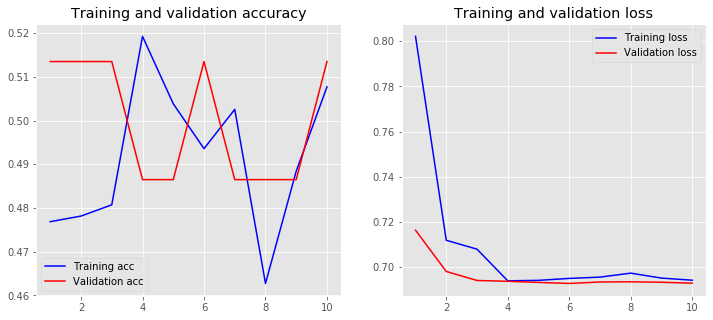

In [15]:
evaluation(loaded_train_test_model,history_1,X_train,y_train,X_test,y_test)

In [16]:
# clear_session()

# Model without first lstm layer

In [17]:
def Model_without_first_lstm_layer():
    model_wihout_lstm = Sequential()

    model_wihout_lstm.add(layers.InputLayer(input_shape=first_layer_output[0].shape))
    model_wihout_lstm.add(Bidirectional(LSTM(units=32 , return_sequences=True)))

    # TextCNN with 4 conv layers
    model_wihout_lstm.add(Conv1D(128, 7, activation='tanh', input_shape=(None, 32)))
    model_wihout_lstm.add(Conv1D(128, 15, activation='tanh'))
    model_wihout_lstm.add(Conv1D(128, 25, activation='tanh'))
    model_wihout_lstm.add(Conv1D(128, 35, activation='tanh'))
    model_wihout_lstm.add(GlobalMaxPooling1D())
    model_wihout_lstm.add(Dense(64, activation='relu'))
    model_wihout_lstm.add(Dropout(0.2))
    model_wihout_lstm.add(Dense(1, activation='sigmoid'))
    model_wihout_lstm.compile(optimizer=myoptimizer,
                  loss=myloss,
                  metrics=[mymetrics])
    model_wihout_lstm.summary()
    return model_wihout_lstm

In [18]:
def fit_Model_without_first_lstm_layer():
    out_lstm_X_train, out_lstm_X_test, out_lstm_y_train, out_lstm_y_test = train_test_split(first_layer_output, y_Data, test_size=0.25, random_state=1000)
    lX_train_List = chunking_data(out_lstm_X_train,9)
    ly_train_List = chunking_data(out_lstm_y_train,9)
    model_wihout_lstm = Model_without_first_lstm_layer()
    lX_test_List = chunking_data(out_lstm_X_test,9)
    ly_test_List = chunking_data(out_lstm_y_test,9)
    history = model_wihout_lstm.fit(lX_train_List[0], ly_train_List[0],
                        epochs=10,
                        verbose=False,
                        validation_data=(lX_test_List[0], ly_test_List[0]))
    model_wihout_lstm.save("model_wihout_lstm.h5")
    for i in range(1,len(lX_train_List)-1):
        loaded_model_wihout_lstm = load_model("model_wihout_lstm.h5")
        loaded_model_wihout_lstm.fit(lX_train_List[i], ly_train_List[i],
                        epochs=10,
                        verbose=False,
                        validation_data=(lX_test_List[i], ly_test_List[i]))
        loaded_model_wihout_lstm.save("model_wihout_lstm.h5")
    return loaded_model_wihout_lstm,history , out_lstm_X_train, out_lstm_X_test, out_lstm_y_train, out_lstm_y_test , "model_wihout_lstm.h5" ,

In [19]:
loaded_model_wihout_lstm,history_2 , out_lstm_X_train, out_lstm_X_test, out_lstm_y_train, out_lstm_y_test , Cpath = fit_Model_without_first_lstm_layer()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional_4 (Bidirection (None, 100, 64)           34048     
_________________________________________________________________
conv1d_8 (Conv1D)            (None, 94, 128)           57472     
_________________________________________________________________
conv1d_9 (Conv1D)            (None, 80, 128)           245888    
_________________________________________________________________
conv1d_10 (Conv1D)           (None, 56, 128)           409728    
_________________________________________________________________
conv1d_11 (Conv1D)           (None, 22, 128)           573568    
_________________________________________________________________
global_max_pooling1d_2 (Glob (None, 128)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 64)               

Training Accuracy: 0.5012
Testing Accuracy:  0.4964


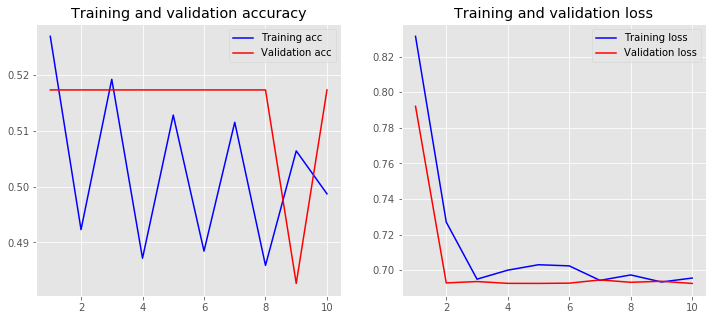

In [20]:
evaluation(loaded_model_wihout_lstm,history_2,out_lstm_X_train,out_lstm_y_train,out_lstm_X_test,out_lstm_y_test)

In [21]:
# clear_session()